## Import necessary library

In [919]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

## Get File path and load the csv data

In [920]:
from util.data_path import cassava_price_avg as data_file

In [921]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [922]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [923]:
SEQ_LEN = 12
PRED_LEN = 12

# Transformer Model And Predict Graph

## Training the Transformer Model

In [924]:
from util.transformer_cust_class import SeqDataset, TransformerRegressor

In [925]:
series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [926]:
EPOCHS = 500
for epoch in range(1, EPOCHS + 1):
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model_tf(xb)  # (B, 12)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — loss = {loss.item():.6f}")


Epoch  50/500 — loss = 0.032903
Epoch 100/500 — loss = 0.023577
Epoch 150/500 — loss = 0.020177
Epoch 200/500 — loss = 0.016905
Epoch 250/500 — loss = 0.014027
Epoch 300/500 — loss = 0.011938
Epoch 350/500 — loss = 0.008884
Epoch 400/500 — loss = 0.008175
Epoch 450/500 — loss = 0.006716
Epoch 500/500 — loss = 0.005845


## Predict the data for the next year

In [927]:
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

In [928]:
cmp = pd.concat([future["price"], tf_forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            price  TF_forecast
2024-01-01   3.65         3.38
2024-02-01   3.65         3.25
2024-03-01   3.57         3.05
2024-04-01   3.24         2.94
2024-05-01   3.19         2.95
2024-06-01   3.09         3.02
2024-07-01   3.06         3.04
2024-08-01   2.95         3.09
2024-09-01   2.86         3.09
2024-10-01   2.65         3.07
2024-11-01   2.60         2.93
2024-12-01   2.32         2.92


## Compare The Error of a predicted data in a table format

In [929]:
error = cmp["price"] - cmp["TF_forecast"]
abs_error = error.abs()

# Guard against division by zero for percentage error
denom = cmp["price"].replace(0, np.nan)
abs_pct_error = (abs_error / denom) * 100

# Metrics
mae_tf = mean_absolute_error(cmp["price"], cmp["TF_forecast"])
mape_tf = abs_pct_error.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors (Transformer) ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["price"],
        "forecast": cmp["TF_forecast"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,
    }
)
print(error_df.round(4))

print(f"\nTransformer MAE (2024): {mae_tf:.6f}")
print(f"Transformer MAPE (2024): {mape_tf:.4f}%")
print(f"Transformer Accuracy = {100 - (mae_tf / cmp['price'].mean() * 100):.2f}%")
# ...existing code...


--- Monthly Errors (Transformer) ---
            actual  forecast   error  abs_error  abs_pct_error
2024-01-01    3.65    3.3756  0.2744     0.2744         7.5170
2024-02-01    3.65    3.2485  0.4015     0.4015        10.9998
2024-03-01    3.57    3.0493  0.5207     0.5207        14.5865
2024-04-01    3.24    2.9438  0.2962     0.2962         9.1435
2024-05-01    3.19    2.9471  0.2429     0.2429         7.6135
2024-06-01    3.09    3.0233  0.0667     0.0667         2.1584
2024-07-01    3.06    3.0384  0.0216     0.0216         0.7045
2024-08-01    2.95    3.0931 -0.1431     0.1431         4.8498
2024-09-01    2.86    3.0898 -0.2298     0.2298         8.0339
2024-10-01    2.65    3.0691 -0.4191     0.4191        15.8142
2024-11-01    2.60    2.9304 -0.3304     0.3304        12.7086
2024-12-01    2.32    2.9206 -0.6006     0.6006        25.8888

Transformer MAE (2024): 0.295578
Transformer MAPE (2024): 10.0015%
Transformer Accuracy = 90.37%


In [930]:
import os

forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "Transformer"
forecast_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(f"LSTM Forecast Results for Soybean Prices (2024) {timestamp}\n")
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in tf_forecast.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Tf_forecast Price: {tf_forecast.mean():.2f}\n")
    f.write(f"Min Tf_forecast Price: {tf_forecast.min():.2f}\n")
    f.write(f"Max Tf_forecast Price: {tf_forecast.max():.2f}\n")
    f.write(f"Standard Deviation: {tf_forecast.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\Transformer\cassava_forecast.txt
File size: 532 bytes


## Plot The predicted data compare to an actual data

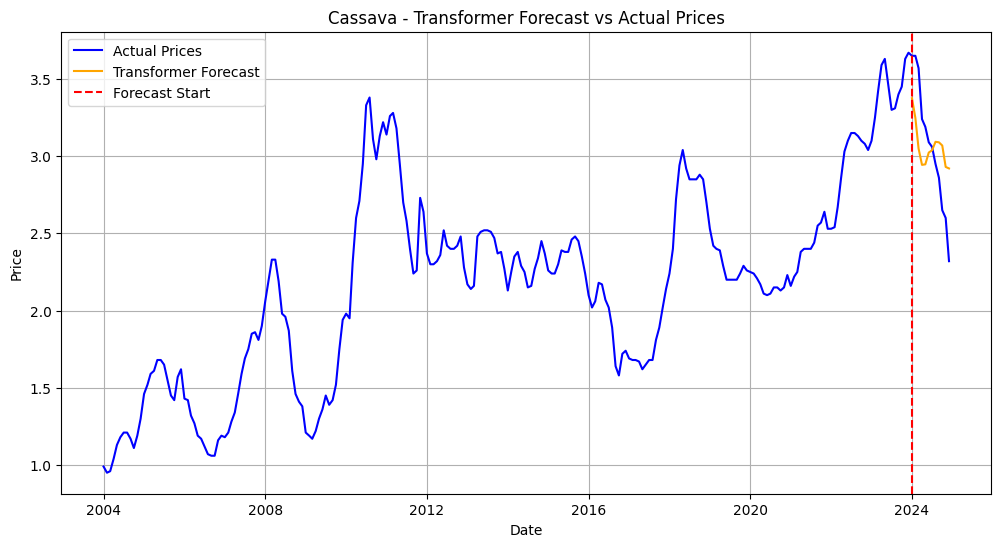

In [931]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title(
    f"{data_file.parent.name.capitalize()} - Transformer Forecast vs Actual Prices"
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# Transformer Model And Error Graph

## PLot the Error Analysis graph

<Figure size 1400x800 with 0 Axes>

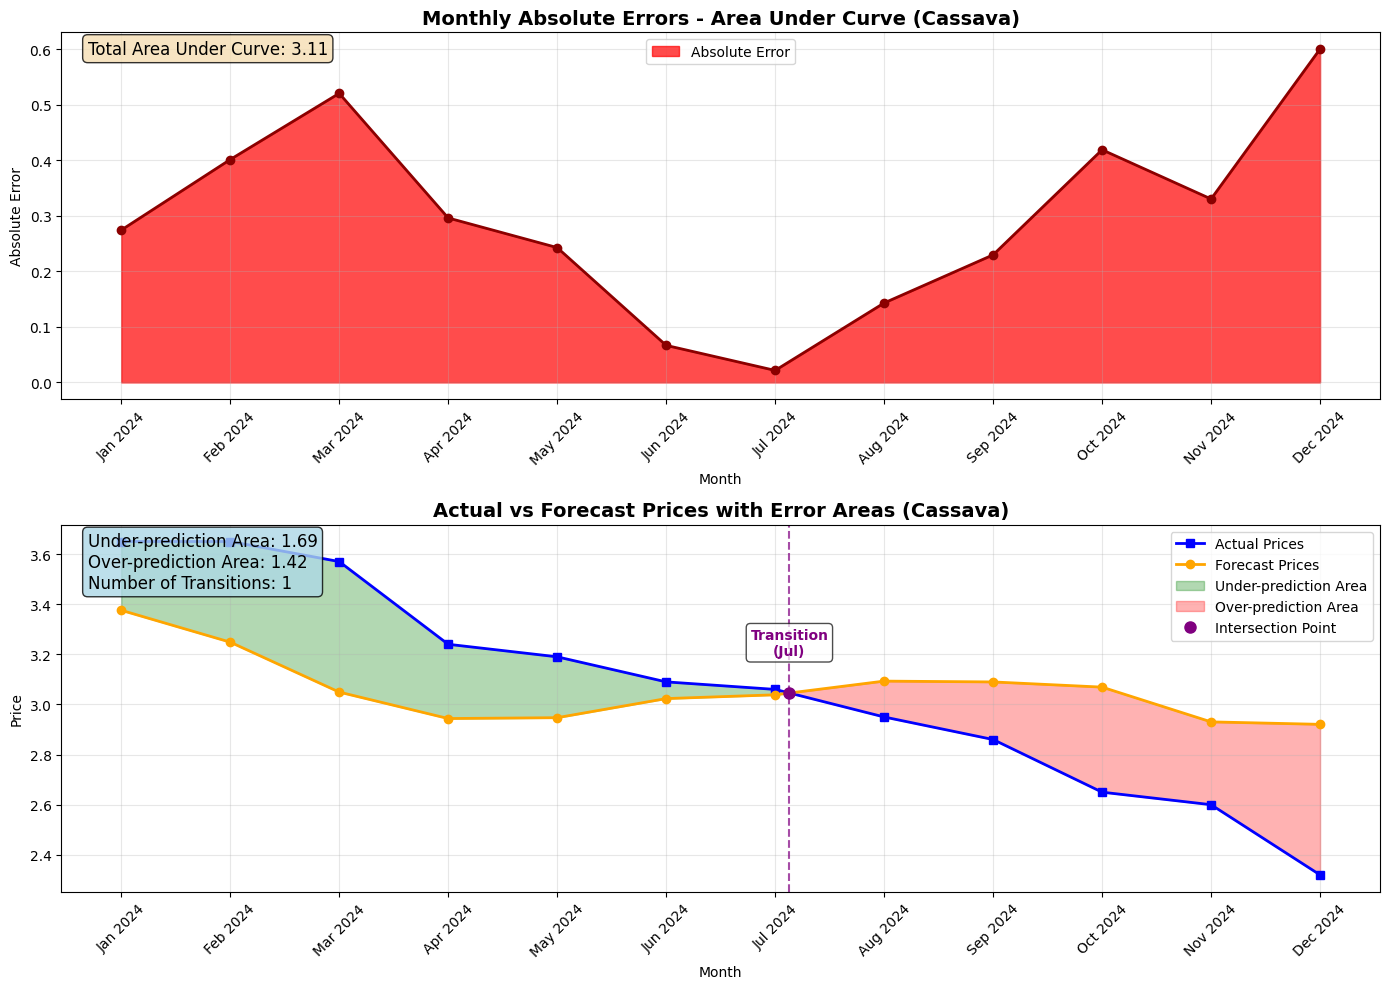

In [932]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["price"] - cmp["TF_forecast"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["price"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["TF_forecast"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["price"].iloc[i - 1] - cmp["TF_forecast"].iloc[i - 1]
    curr_diff = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["price"].iloc[i - 1] + t * (
            cmp["price"].iloc[i] - cmp["price"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] >= cmp["TF_forecast"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] < cmp["TF_forecast"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["price"] - cmp["TF_forecast"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["TF_forecast"] - cmp["price"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data

In [933]:
print("\n--- Area Under Curve Analysis ---")
print(f"Total Absolute Error Area: {total_area:.4f}")
print(f"Under-prediction Area: {under_pred_area:.4f}")
print(f"Over-prediction Area: {over_pred_area:.4f}")
print(f"Net Error Area: {under_pred_area - over_pred_area:.4f}")
print(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}")
print(f"Number of Transition Points: {len(intersect_indices)}")

# Monthly breakdown
print("\n--- Monthly Error Areas ---")
for i, (date, row) in enumerate(cmp.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["price"] > row["TF_forecast"]
        else "Over-prediction"
        if row["price"] < row["TF_forecast"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {row['abs_error']:.4f} ({error_type})")

# Transition analysis
if intersect_indices:
    print("\n--- Transition Points ---")
    for idx, (x, y) in enumerate(intersect_indices):
        transition_month = month_labels[int(x)]
        next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
        print(
            f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}"
        )

        # Determine transition type
        i = int(x)
        if i + 1 < len(cmp):
            before_error = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]
            after_error = cmp["price"].iloc[i + 1] - cmp["TF_forecast"].iloc[i + 1]
            direction = (
                "Under to Over"
                if before_error > 0 and after_error < 0
                else "Over to Under"
            )
            print(f"   Direction: {direction} prediction")
else:
    print("\n--- No Transition Points Found ---")
    print(
        "The model consistently either under-predicts or over-predicts throughout the entire period."
    )


--- Area Under Curve Analysis ---
Total Absolute Error Area: 3.1094
Under-prediction Area: 1.6868
Over-prediction Area: 1.4227
Net Error Area: 0.2641
Average Monthly Absolute Error: 0.2591
Number of Transition Points: 1

--- Monthly Error Areas ---
Jan 2024: Abs Error = 0.2744 (Under-prediction)
Feb 2024: Abs Error = 0.4015 (Under-prediction)
Mar 2024: Abs Error = 0.5207 (Under-prediction)
Apr 2024: Abs Error = 0.2962 (Under-prediction)
May 2024: Abs Error = 0.2429 (Under-prediction)
Jun 2024: Abs Error = 0.0667 (Under-prediction)
Jul 2024: Abs Error = 0.0216 (Under-prediction)
Aug 2024: Abs Error = 0.1431 (Over-prediction)
Sep 2024: Abs Error = 0.2298 (Over-prediction)
Oct 2024: Abs Error = 0.4191 (Over-prediction)
Nov 2024: Abs Error = 0.3304 (Over-prediction)
Dec 2024: Abs Error = 0.6006 (Over-prediction)

--- Transition Points ---
Transition 1: Between Jul 2024 and Aug 2024 at position 6.13
   Direction: Under to Over prediction


## Save the model Error Analysis to a file 

In [934]:
error_record_dir = Path("error_record") / "Transformer"
error_record_dir.mkdir(exist_ok=True, parents=True)

crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = error_record_dir / filename

In [935]:
mae_value = mae_tf
mape_value = mape_tf
accuracy = 100 - (mae_tf / cmp["price"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save metrics to text file
with open(filepath, "w") as f:
    f.write(
        f"Transformer Model Evaluation Metrics for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Overall Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Monthly Evaluation:\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for date, row in error_df.iterrows():
        month_label = date.strftime("%b %Y")
        f.write(
            f"{month_label:<10} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nArea Under Curve Analysis:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area - over_pred_area:.4f}\n")
    f.write(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}\n")
    f.write(f"Number of Transition Points: {len(intersect_indices)}\n")

    # Add transition information
    if intersect_indices:
        f.write("\nTransition Points:\n")
        f.write("-" * 20 + "\n")
        for idx, (x, y) in enumerate(intersect_indices):
            transition_month = month_labels[int(x)]
            next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
            f.write(
                f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}\n"
            )

            # Determine transition type
            i = int(x)
            if i + 1 < len(cmp):
                before_error = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]
                after_error = cmp["price"].iloc[i + 1] - cmp["TF_forecast"].iloc[i + 1]
                direction = (
                    "Under to Over"
                    if before_error > 0 and after_error < 0
                    else "Over to Under"
                )
                f.write(f"   Direction: {direction} prediction\n")

print(f"Evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Evaluation metrics saved to: error_record\Transformer\cassava_error_metrics.txt
File size: 1600 bytes
